In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
# Basic settings
NUM_WORDS = 10000
MAX_LEN = 200

# Load dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=NUM_WORDS)

# Padding
x_train = pad_sequences(x_train, maxlen=MAX_LEN)
x_test = pad_sequences(x_test, maxlen=MAX_LEN)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Build Simple RNN model
model = models.Sequential([
    layers.Embedding(input_dim=NUM_WORDS, output_dim=32, input_length=MAX_LEN),
    layers.SimpleRNN(32),
    layers.Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',     # watch validation loss
    patience=2,             # stop after 2 epochs with no improvement
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_rnn_model.keras', # file name
    monitor='val_accuracy', # save best accuracy model
    save_best_only=True
)


In [ ]:
# Train
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.6094 - loss: 0.6457 - val_accuracy: 0.7566 - val_loss: 0.5062
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8277 - loss: 0.3965 - val_accuracy: 0.7982 - val_loss: 0.4402
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8858 - loss: 0.2873 - val_accuracy: 0.8372 - val_loss: 0.3856
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9413 - loss: 0.1645 - val_accuracy: 0.8458 - val_loss: 0.4286
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9772 - loss: 0.0797 - val_accuracy: 0.8214 - val_loss: 0.4908
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8320 - loss: 0.3959
Test Accuracy: 0.8319600224494934


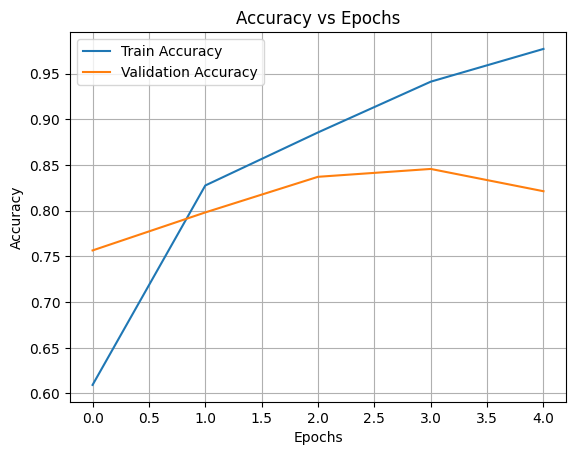

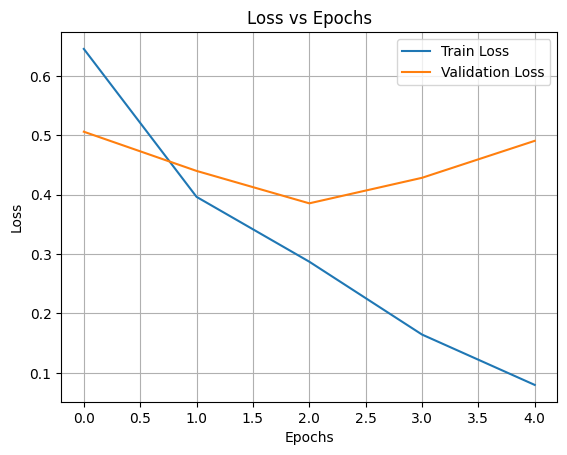

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    # Accuracy plot
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()

    # Loss plot
    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.show()

# 👉 Call function AFTER defining it
plot_history(history)